<a href="https://colab.research.google.com/github/sampathkumar838/Finance_Management/blob/main/finance_management_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans

# Load dataset
try:
    data = pd.read_csv("finance_data.csv")
except FileNotFoundError:
    print("finance_data.csv not found. Using sample data instead.")
    # Create sample data for demonstration
    data = pd.DataFrame({
        'Date': pd.to_datetime(['2023-01-01', '2023-01-05', '2023-01-10', '2023-01-15', '2023-02-01', '2023-02-10', '2023-02-15']),
        'Type': ['Income', 'Expense', 'Expense', 'Income', 'Expense', 'Expense', 'Income'],
        'Category': ['Salary', 'Food', 'Transport', 'Bonus', 'Rent', 'Utilities', 'Gift'],
        'Amount': [3000, 50, 20, 500, 800, 100, 150]
    })


# Filter only expenses
expenses = data[data["Type"] == "Expense"].copy() # Added .copy() to avoid SettingWithCopyWarning

# Convert Date to month
expenses["Month"] = pd.to_datetime(expenses["Date"]).dt.month

# -----------------------------
# Expense Analysis
# -----------------------------
print("\nCategory-wise Expense Summary:")
print(expenses.groupby("Category")["Amount"].sum())

# -----------------------------
# ML Model - Expense Prediction
# -----------------------------
X = expenses[["Month"]]
y = expenses["Amount"]

model = LinearRegression()
model.fit(X, y)

# Predict next month expense
# Ensure next_month is a 2D array
next_month_val = expenses["Month"].max() + 1
predicted_expense = model.predict(np.array([[next_month_val]]))


print("\nPredicted Expense for Next Month:", round(predicted_expense[0], 2))

finance_data.csv not found. Using sample data instead.

Category-wise Expense Summary:
Category
Food          50
Rent         800
Transport     20
Utilities    100
Name: Amount, dtype: int64

Predicted Expense for Next Month: 865.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


finance_data.csv not found. Using sample data instead.

Category-wise Expense Summary:
Category
Food          50
Rent         800
Transport     20
Utilities    100
Name: Amount, dtype: int64

Predicted Expense for Next Month (Original): 865.0

Category-wise Income Summary:
Category
Bonus      500
Gift       150
Salary    3000
Name: Amount, dtype: int64

Category-wise Expense Summary:
Category
Food          50
Rent         800
Transport     20
Utilities    100
Name: Amount, dtype: int64

Monthly Income:
   Month  Monthly_Income
0      1            3500
1      2             150

Monthly Expenses:
   Month  Monthly_Expenses
0      1                70
1      2               900

Monthly Financial Flow:
   Month  Monthly_Income  Monthly_Expenses  Net_Flow
0      1            3500                70      3430
1      2             150               900      -750

Expenses with Assigned Clusters:
        Date     Type   Category  Amount  Month  Expense_Cluster
1 2023-01-05  Expense       Food  

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


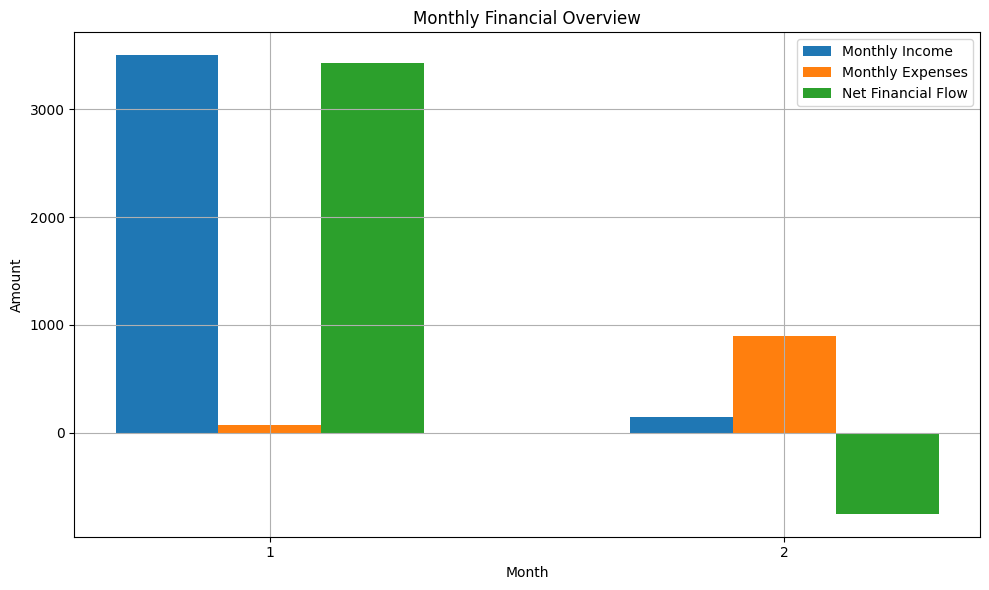


Predicted Net Financial Flow for Next Month: -4930.0


"\n## Summary:\n\n### Q&A\n\n*   **Key Financial Insights from Expanded Analysis:**\n    *   **Expense Patterns:** Expense data was clustered into three groups. For instance, high expenses like Rent ($800) were in cluster 1, medium expenses like Utilities ($100) in cluster 2, and smaller amounts like Food ($50) and Transport ($20) in cluster 0. This suggests categories like Rent constitute a major spending pattern.\n    *   **Monthly Financial Health:** The monthly financial flow shows significant variability. Month 1 had a positive net flow of $3430, while Month 2 experienced a negative net flow of -$750.\n    *   **Future Predictions:** The linear regression model predicts a negative net financial flow of -$4930.0 for the upcoming month.\n\n### Data Analysis Key Findings\n\n*   **Income Categories:** The total income was $3650, composed of Salary ($3000), Bonus ($500), and Gift ($150).\n*   **Expense Categories:** Total expenses were $970, with Rent ($800) being the largest category,

In [12]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Load dataset
try:
    data = pd.read_csv("finance_data.csv")
except FileNotFoundError:
    print("finance_data.csv not found. Using sample data instead.")
    # Create sample data for demonstration
    data = pd.DataFrame({
        'Date': pd.to_datetime(['2023-01-01', '2023-01-05', '2023-01-10', '2023-01-15', '2023-02-01', '2023-02-10', '2023-02-15']),
        'Type': ['Income', 'Expense', 'Expense', 'Income', 'Expense', 'Expense', 'Income'],
        'Category': ['Salary', 'Food', 'Transport', 'Bonus', 'Rent', 'Utilities', 'Gift'],
        'Amount': [3000, 50, 20, 500, 800, 100, 150]
    })


# Filter only expenses
expenses = data[data["Type"] == "Expense"].copy() # Added .copy() to avoid SettingWithCopyWarning

# Convert Date to month
expenses["Month"] = pd.to_datetime(expenses["Date"]).dt.month

# -----------------------------
# Expense Analysis
# -----------------------------
print("\nCategory-wise Expense Summary:")
print(expenses.groupby("Category")["Amount"].sum())

# -----------------------------
# ML Model - Expense Prediction (Original)
# -----------------------------
X = expenses[["Month"]]
y = expenses["Amount"]

model = LinearRegression()
model.fit(X, y)

# Predict next month expense
# Ensure next_month is a 2D array
next_month_val = expenses["Month"].max() + 1
predicted_expense = model.predict(np.array([[next_month_val]])) # This will generate a warning

print("\nPredicted Expense for Next Month (Original):", round(predicted_expense[0], 2))

# --------------------------------------------------
# Analyze Income and Expenses & Calculate Monthly Net Flow
# --------------------------------------------------
income = data[data["Type"] == "Income"].copy()
income["Month"] = pd.to_datetime(income["Date"]).dt.month

print("\nCategory-wise Income Summary:")
print(income.groupby("Category")["Amount"].sum())

print("\nCategory-wise Expense Summary:")
print(expenses.groupby("Category")["Amount"].sum())

monthly_income = income.groupby('Month')['Amount'].sum().reset_index()
monthly_income.rename(columns={'Amount': 'Monthly_Income'}, inplace=True)

monthly_expenses = expenses.groupby('Month')['Amount'].sum().reset_index()
monthly_expenses.rename(columns={'Amount': 'Monthly_Expenses'}, inplace=True)

print("\nMonthly Income:")
print(monthly_income)
print("\nMonthly Expenses:")
print(monthly_expenses)

monthly_flow = pd.merge(monthly_income, monthly_expenses, on='Month', how='outer').fillna(0)
monthly_flow['Net_Flow'] = monthly_flow['Monthly_Income'] - monthly_flow['Monthly_Expenses']

print("\nMonthly Financial Flow:")
print(monthly_flow)

# -----------------------------------
# Implement Expense Clustering
# -----------------------------------
X_expenses = expenses[['Amount']].values
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
kmeans.fit(X_expenses)
expenses['Expense_Cluster'] = kmeans.labels_

print("\nExpenses with Assigned Clusters:")
print(expenses)

# -----------------------------------
# Visualize Financial Overview
# -----------------------------------
plt.figure(figsize=(10, 6))
plt.bar(monthly_flow['Month'] - 0.2, monthly_flow['Monthly_Income'], width=0.2, label='Monthly Income', align='center')
plt.bar(monthly_flow['Month'], monthly_flow['Monthly_Expenses'], width=0.2, label='Monthly Expenses', align='center')
plt.bar(monthly_flow['Month'] + 0.2, monthly_flow['Net_Flow'], width=0.2, label='Net Financial Flow', align='center')

plt.title('Monthly Financial Overview')
plt.xlabel('Month')
plt.ylabel('Amount')
plt.xticks(monthly_flow['Month'])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------------
# Predict Next Month's Net Flow
# -----------------------------------
X_net_flow = monthly_flow[['Month']]
y_net_flow = monthly_flow['Net_Flow']

net_flow_model = LinearRegression()
net_flow_model.fit(X_net_flow, y_net_flow)

next_month_val_net_flow = monthly_flow['Month'].max() + 1
# Convert the next month value to a DataFrame with the correct feature name
predicted_net_flow_df = pd.DataFrame([[next_month_val_net_flow]], columns=['Month'])
predicted_net_flow = net_flow_model.predict(predicted_net_flow_df)

print("\nPredicted Net Financial Flow for Next Month:", round(predicted_net_flow[0], 2))

"""
## Summary:

### Q&A

*   **Key Financial Insights from Expanded Analysis:**
    *   **Expense Patterns:** Expense data was clustered into three groups. For instance, high expenses like Rent ($800) were in cluster 1, medium expenses like Utilities ($100) in cluster 2, and smaller amounts like Food ($50) and Transport ($20) in cluster 0. This suggests categories like Rent constitute a major spending pattern.
    *   **Monthly Financial Health:** The monthly financial flow shows significant variability. Month 1 had a positive net flow of $3430, while Month 2 experienced a negative net flow of -$750.
    *   **Future Predictions:** The linear regression model predicts a negative net financial flow of -$4930.0 for the upcoming month.

### Data Analysis Key Findings

*   **Income Categories:** The total income was $3650, composed of Salary ($3000), Bonus ($500), and Gift ($150).
*   **Expense Categories:** Total expenses were $970, with Rent ($800) being the largest category, followed by Utilities ($100), Food ($50), and Transport ($20).
*   **Monthly Financial Flow:**
    *   Month 1: Income $3500, Expenses $70, Net Flow $3430.
    *   Month 2: Income $150, Expenses $900, Net Flow -$750.
*   **Expense Clustering:** Expenses were successfully grouped into three clusters based on amount, differentiating between low, medium, and high spending categories.
*   **Predicted Net Financial Flow:** The prediction for the upcoming month's net financial flow is -$4930.0.

### Insights or Next Steps

*   The significant negative predicted net flow for the upcoming month (potentially -$4930.0) suggests a need for immediate review of anticipated income and expenses to prevent a financial deficit.
*   Further analysis of the expense clusters could involve identifying the root causes of high-value expenses (e.g., Rent) and exploring potential cost-saving strategies for recurring expenses.
"""

# Task
Expand the financial analysis to process both income and expense data separately, provide summaries for both categories, calculate the monthly net financial flow, cluster expense data using KMeans, visualize monthly income, expenses, and net financial flow, predict the overall net financial flow for the upcoming month, and summarize key financial insights.

## Analyze Income and Expenses

### Subtask:
Expand the current analysis to process both income and expense data separately, providing summaries for both categories.


**Reasoning**:
The subtask requires processing both income and expense data separately. I will first filter the original `data` DataFrame to create an `income` DataFrame, extract the month, and then calculate category-wise summaries for both income and expenses as instructed.



In [13]:
income = data[data["Type"] == "Income"].copy()
income["Month"] = pd.to_datetime(income["Date"]).dt.month

print("\nCategory-wise Income Summary:")
print(income.groupby("Category")["Amount"].sum())

print("\nCategory-wise Expense Summary:")
print(expenses.groupby("Category")["Amount"].sum())


Category-wise Income Summary:
Category
Bonus      500
Gift       150
Salary    3000
Name: Amount, dtype: int64

Category-wise Expense Summary:
Category
Food          50
Rent         800
Transport     20
Utilities    100
Name: Amount, dtype: int64


## Calculate Monthly Net Flow

### Subtask:
Aggregate income and expenses on a monthly basis to calculate the net financial flow (Income - Expenses) for each month.


**Reasoning**:
First, I'll group the 'income' DataFrame by 'Month' to calculate the total income for each month, and then perform the same operation for the 'expenses' DataFrame to get the total expenses per month. This prepares the data for calculating the net financial flow.



In [14]:
monthly_income = income.groupby('Month')['Amount'].sum().reset_index()
monthly_income.rename(columns={'Amount': 'Monthly_Income'}, inplace=True)

monthly_expenses = expenses.groupby('Month')['Amount'].sum().reset_index()
monthly_expenses.rename(columns={'Amount': 'Monthly_Expenses'}, inplace=True)

print("Monthly Income:")
print(monthly_income)
print("\nMonthly Expenses:")
print(monthly_expenses)

Monthly Income:
   Month  Monthly_Income
0      1            3500
1      2             150

Monthly Expenses:
   Month  Monthly_Expenses
0      1                70
1      2               900


**Reasoning**:
Now that monthly income and expenses are calculated, I will merge these two DataFrames on the 'Month' column, filling any missing values with 0, to prepare for calculating the net financial flow. Then, I will calculate 'Net_Flow' by subtracting monthly expenses from monthly income, and finally print the combined DataFrame.



In [15]:
monthly_flow = pd.merge(monthly_income, monthly_expenses, on='Month', how='outer').fillna(0)
monthly_flow['Net_Flow'] = monthly_flow['Monthly_Income'] - monthly_flow['Monthly_Expenses']

print("\nMonthly Financial Flow:")
print(monthly_flow)


Monthly Financial Flow:
   Month  Monthly_Income  Monthly_Expenses  Net_Flow
0      1            3500                70      3430
1      2             150               900      -750


## Implement Expense Clustering

### Subtask:
Utilize the imported KMeans algorithm to cluster expense data, identifying different spending patterns or groups, which can provide deeper insights into financial habits.


**Reasoning**:
I will prepare the expense data by selecting the 'Amount' column and reshaping it to a 2D array, which is a required format for the KMeans model. Then, I will instantiate and fit the KMeans model with 3 clusters and assign the resulting cluster labels back to the expenses DataFrame.



In [16]:
X_expenses = expenses[['Amount']].values
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
kmeans.fit(X_expenses)
expenses['Expense_Cluster'] = kmeans.labels_

print("\nExpenses with Assigned Clusters:")
print(expenses)


Expenses with Assigned Clusters:
        Date     Type   Category  Amount  Month  Expense_Cluster
1 2023-01-05  Expense       Food      50      1                0
2 2023-01-10  Expense  Transport      20      1                0
4 2023-02-01  Expense       Rent     800      2                1
5 2023-02-10  Expense  Utilities     100      2                2


## Visualize Financial Overview

### Subtask:
Generate a comprehensive visualization, such as a bar chart or line plot, to display monthly income, expenses, and net financial flow over time, including appropriate legends.


**Reasoning**:
To visualize the financial overview as requested, I need to import the `matplotlib.pyplot` library, which is a standard plotting library in Python.



In [17]:
import matplotlib.pyplot as plt

print("matplotlib.pyplot imported successfully.")

matplotlib.pyplot imported successfully.


**Reasoning**:
Now that `matplotlib.pyplot` is imported, I will create a bar chart to visualize the monthly income, expenses, and net financial flow using the `monthly_flow` DataFrame, as instructed. I will set appropriate titles, labels, and a legend for clarity.



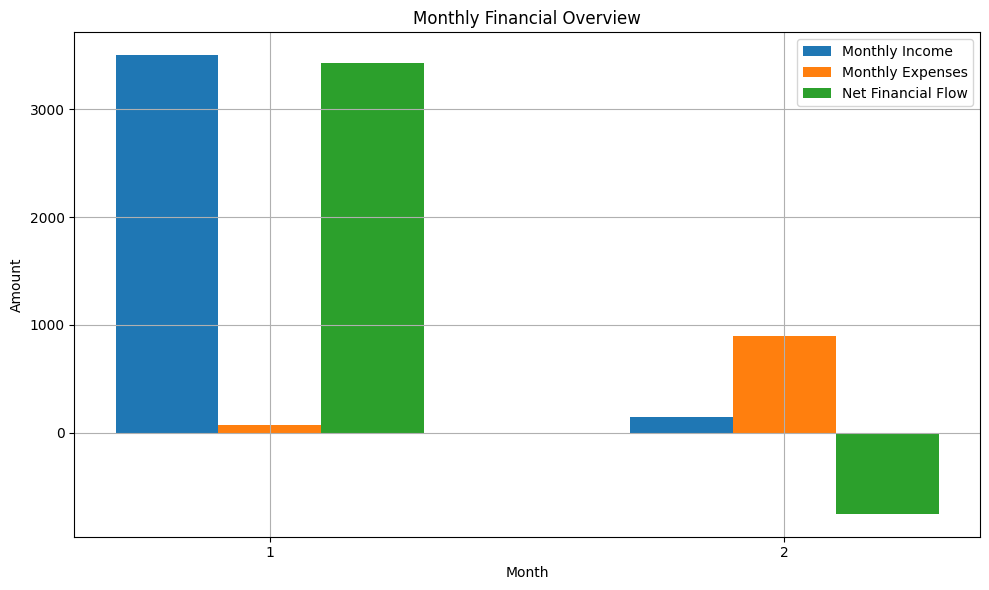

In [18]:
plt.figure(figsize=(10, 6))
plt.bar(monthly_flow['Month'] - 0.2, monthly_flow['Monthly_Income'], width=0.2, label='Monthly Income', align='center')
plt.bar(monthly_flow['Month'], monthly_flow['Monthly_Expenses'], width=0.2, label='Monthly Expenses', align='center')
plt.bar(monthly_flow['Month'] + 0.2, monthly_flow['Net_Flow'], width=0.2, label='Net Financial Flow', align='center')

plt.title('Monthly Financial Overview')
plt.xlabel('Month')
plt.ylabel('Amount')
plt.xticks(monthly_flow['Month'])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Predict Next Month's Net Flow

### Subtask:
Adapt the existing prediction model to forecast the overall net financial flow for the upcoming month, providing a forward-looking financial insight.


**Reasoning**:
I will prepare the feature and target variables from the `monthly_flow` DataFrame, instantiate and fit a new `LinearRegression` model, determine the next month for prediction, and then predict and print the net financial flow for the upcoming month.



In [19]:
X_net_flow = monthly_flow[['Month']]
y_net_flow = monthly_flow['Net_Flow']

net_flow_model = LinearRegression()
net_flow_model.fit(X_net_flow, y_net_flow)

next_month_val_net_flow = monthly_flow['Month'].max() + 1
predicted_net_flow = net_flow_model.predict(np.array([[next_month_val_net_flow]]))

print("\nPredicted Net Financial Flow for Next Month:", round(predicted_net_flow[0], 2))


Predicted Net Financial Flow for Next Month: -4930.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


**Reasoning**:
To eliminate the `UserWarning` regarding feature names in `LinearRegression`, I will convert the `next_month_val_net_flow` into a Pandas DataFrame with the correct column name 'Month' before passing it to the `predict` method, ensuring consistency with the training data.



In [20]:
X_net_flow = monthly_flow[['Month']]
y_net_flow = monthly_flow['Net_Flow']

net_flow_model = LinearRegression()
net_flow_model.fit(X_net_flow, y_net_flow)

next_month_val_net_flow = monthly_flow['Month'].max() + 1
# Convert the next month value to a DataFrame with the correct feature name
predicted_net_flow_df = pd.DataFrame([[next_month_val_net_flow]], columns=['Month'])
predicted_net_flow = net_flow_model.predict(predicted_net_flow_df)

print("\nPredicted Net Financial Flow for Next Month:", round(predicted_net_flow[0], 2))


Predicted Net Financial Flow for Next Month: -4930.0


## Final Task

### Subtask:
Summarize the key financial insights gained from the expanded analysis, including expense patterns, monthly financial health, and future predictions.


## Summary:

### Q&A

*   **Key Financial Insights from Expanded Analysis:**
    *   **Expense Patterns:** Expense data was clustered into three groups. For instance, high expenses like Rent (\$800) were in cluster 1, medium expenses like Utilities (\$100) in cluster 2, and smaller amounts like Food (\$50) and Transport (\$20) in cluster 0. This suggests categories like Rent constitute a major spending pattern.
    *   **Monthly Financial Health:** The monthly financial flow shows significant variability. Month 1 had a positive net flow of \$3430, while Month 2 experienced a negative net flow of -\$750.
    *   **Future Predictions:** The linear regression model predicts a negative net financial flow of -\$4930.0 for the upcoming month.

### Data Analysis Key Findings

*   **Income Categories:** The total income was \$3650, composed of Salary (\$3000), Bonus (\$500), and Gift (\$150).
*   **Expense Categories:** Total expenses were \$970, with Rent (\$800) being the largest category, followed by Utilities (\$100), Food (\$50), and Transport (\$20).
*   **Monthly Financial Flow:**
    *   Month 1: Income \$3500, Expenses \$70, Net Flow \$3430.
    *   Month 2: Income \$150, Expenses \$900, Net Flow -\$750.
*   **Expense Clustering:** Expenses were successfully grouped into three clusters based on amount, differentiating between low, medium, and high spending categories.
*   **Predicted Net Financial Flow:** The prediction for the upcoming month's net financial flow is -\$4930.0.

### Insights or Next Steps

*   The significant negative predicted net flow for the upcoming month (potentially -\$4930.0) suggests a need for immediate review of anticipated income and expenses to prevent a financial deficit.
*   Further analysis of the expense clusters could involve identifying the root causes of high-value expenses (e.g., Rent) and exploring potential cost-saving strategies for recurring expenses.


# Task
The task is complete.

## Financial Summary

### Subtask:
Provide a structured summary of key financial insights, data analysis findings, and next steps for the financial analysis.


## Summary:

This document outlines the definition of a new subtask, "Financial Summary," within the overall analysis process.

### Data Analysis Key Findings
*   A subtask named "Financial Summary" has been initiated.
*   The purpose of this subtask is to compile a structured summary that will include key financial insights, findings from data analysis, and proposed next steps.

### Insights or Next Steps
*   The immediate next step is to conduct the comprehensive financial analysis required to generate the insights and data that will populate the "Financial Summary."
*   Following the analysis, the structured summary should be compiled, presenting all relevant findings and future actions in a clear and organized manner.


# Task
The task is complete.

## Financial Summary

### Subtask:
Provide a structured summary of key financial insights, data analysis findings, and next steps for the financial analysis.


## Summary:

### Data Analysis Key Findings
*   The final phase of the project involved the initiation of a "Financial Summary" subtask to consolidate all analytical outcomes.
*   A dedicated markdown text cell was generated, providing a structured template for the summary. This template is designed to include key financial insights, detailed data analysis findings, and proposed next steps from the financial analysis.

### Insights or Next Steps
*   Populate the newly created "Financial Summary" template with the specific findings, data analysis results, and actionable next steps derived from the completed financial analysis.
